In this part, we want to analyse the data we generated. 

# imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# file paths

In [2]:
# these are the files you just generated using the napari interface. 
cy3_spots = '../cy3_spots.pkl'
cy5_spots = '../cy5_spots.pkl'
cell_labels = '../segmentation.pkl'

In [3]:
cells = pd.read_pickle(cell_labels)

In [4]:
cells

,cell_label
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


# cy 5 channel

In [ ]:
cy5_spots_data = pd.read_pickle(cy5_spots)


,row,column,cell_id,spot_intensities,nuclear_intensity
0,292,342,6,10721,9186
1,297,349,6,10155,8299
2,155,321,4,10264,5466
3,82,80,1,10153,5988
4,134,375,3,9807,21325
...,...,...,...,...,...
1145,549,665,27,4102,6940
1146,529,448,26,4110,5761
1147,517,321,23,4728,5225
1148,146,351,3,4825,5257


In [13]:
#inspect data 
cy5_spots_data.head()
cy5_spots_data[cy5_spots_data["cell_id"] == 14]

,row,column,cell_id,spot_intensities,nuclear_intensity
0,380,140,14,5811,32817
53,345,173,14,2125,8961
75,356,136,14,2465,8503
78,362,110,14,1879,4130
116,365,158,14,2139,20020
190,348,139,14,2003,8057
197,340,158,14,1851,7998
217,371,133,14,2097,14634
220,378,123,14,1715,8257
222,350,144,14,1962,8870


In [ ]:
# plot histograms of spots per cell:

### cy 5 - transcripts per cell 

/tmp/ipykernel_30948/4231196309.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cy5_counts = (cy5_spots_data.groupby('cell_id').apply(lambda x: len(x)).to_frame()


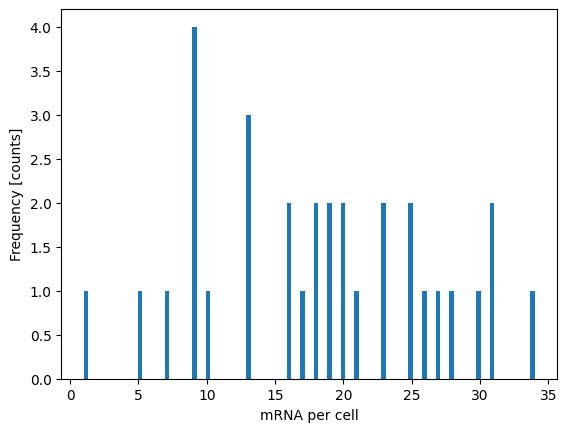

In [11]:
cy5_counts = (cy5_spots_data.groupby('cell_id').apply(lambda x: len(x)).to_frame()
).merge(cells, left_index=True, right_on='cell_label', how='outer').fillna(value=0)

cy5_counts.columns = ['counts','cell_label']

cy5_counts['counts'].plot(kind='hist', bins=100)

plt.xlabel('mRNA per cell')
plt.ylabel('Frequency [counts]')
# adjust bin number to better visualise distribution

plt.savefig('../../Results/notebooks/cy5_transcripts_per_cell.png')

### cy5 - mRNAs per transcription site

In [ ]:
intensities = cy5_spots_data['spot_intensities']
mean_intensity = np.mean(intensities)
transcription_site_threshold = 1.5 * mean_intensity
cy5_spots_data['transcription_site_candidate'] = intensities > transcription_site_threshold

# check the max projection of the DAPI channel for appropriate intensities
# find appropriate values in napari
nuclear_intensity_threshold = 0.8

cy5_spots_data['nuclear_localisation'] = cy5_spots_data['nuclear_intensity'] > nuclear_intensity_threshold
cy5_spots_data['transcription_sites'] = (
    cy5_spots_data['transcription_site_candidate'] & cy5_spots_data['nuclear_localisation'])

(cy5_spots_data[cy5_spots_data['transcription_sites']]['spot_intensities']/mean_intensity).plot(kind='hist')

plt.savefig('cy5_mRNAs_per_transcription_site.png')

# cy 3 channel

In [ ]:
cy3_spots_data = pd.read_pickle(cy3_spots)

In [ ]:
#inspect data 
cy3_spots_data.head()

### cy 3 - transcripts per cell 

In [ ]:
cy3_counts = (cy3_spots_data.groupby('cell_id').apply(lambda x: len(x)).to_frame()
).merge(cells, left_index=True, right_on='cell_label', how='outer').fillna(value=0)

cy3_counts.columns = ['counts','cell_label']

cy3_counts['counts'].plot(kind='hist', bins=100)

plt.xlabel('mRNA per cell')
plt.ylabel('Frequency [counts]')
# adjust bin number to better visualise distribution

plt.savefig('cy3_transcripts_per_cell.png')

### cy3 - mRNAs per transcription site

In [ ]:
intensities = cy3_spots_data['spot_intensities']
mean_intensity = np.mean(intensities)
transcription_site_threshold = 1.5 * mean_intensity
cy3_spots_data['transcription_site_candidate'] = intensities > transcription_site_threshold

# check the max proejction of the DAPI channel for appropriate intensities
# find appropriate values in napari
nuclear_intensity_threshold = 0.8

cy3_spots_data['nuclear_localisation'] = cy3_spots_data['nuclear_intensity'] > nuclear_intensity_threshold
cy3_spots_data['transcription_sites'] = (
    cy3_spots_data['transcription_site_candidate'] & cy3_spots_data['nuclear_localisation'])

(cy3_spots_data[cy3_spots_data['transcription_sites']]['spot_intensities']/mean_intensity).plot(kind='hist')

plt.savefig('cy3_mRNAs_per_transcription_site.png')